In [ ]:
# Differential Equation Solver with Initial Conditions
# Python Project - SymPy + Matplotlib

# This notebook allows users to:
# 1. Input a differential equation
# 2. Provide initial conditions
# 3. Solve the equation using SymPy
# 4. Plot the particular solution

In [ ]:
# Import required libraries

from sympy import *
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define symbolic variables
x = symbols('x')
y = Function('y')

In [ ]:
def input_equation():
    """
    Ask the user to input a differential equation.

    Supported syntax:

    y'   -> first derivative (y')
    y^2  -> second derivative (y'')
    y^3  -> third derivative (y^(3))

    For powers use:
    Powers using ^ will automatically be converted to **.
    """

    while True:
        equation = input("Enter a differential equation: ")

        # Convert shorthand derivative notation
        equation = equation.replace("y'", "y.diff(x)")

        for i in range(2, 7):
            equation = equation.replace(f"y^{i}", f"Derivative(y, (x, {i}))")

        equation = equation.replace("y", "y(x)")

        # Convert equation with '=' into expression
        if "=" in equation:
            parts = equation.split("=")
            equation = parts[0] + "-" + parts[1]

        try:
            sympify(equation)
            return sympify(equation)

        except:
            print("Invalid expression. Please try again.")

In [ ]:
def input_conditions():
    """
    Read initial conditions from the user.

    Format:
    (order, x_value, y_value)

    Example:
    y(2) = 3      -> 0,2,3
    y'(2) = 1     -> 1,2,1
    y''(2) = 0    -> 2,2,0
    """

    conditions = []

    print("Enter 'x' to stop entering conditions.")

    while True:

        condition = input("Enter initial condition (order,x,y): ").split(',')

        if condition[0] == 'x':
            break

        conditions.append((int(condition[0]), float(condition[1]), float(condition[2])))

    if conditions:
        print("Initial conditions:")

    conditions_sympy = {}

    for condition in conditions:

        order, x_val, y_val = condition

        if order == 0:
            print(f"y({x_val}) = {y_val}")
            conditions_sympy[y(x_val)] = y_val

        elif order == 1:
            print(f"y'({x_val}) = {y_val}")
            conditions_sympy[y(x).diff(x).subs(x, x_val)] = y_val

        elif order == 2:
            print(f"y''({x_val}) = {y_val}")
            conditions_sympy[y(x).diff(x,2).subs(x, x_val)] = y_val

        elif order > 2:

            for i in range(3, order+1):
                conditions_sympy[y(x).diff(x,i).subs(x, x_val)] = y_val

            print(f"y^{order}({x_val}) = {y_val}")

        else:
            print("Derivative order must be a positive integer.")

    return conditions_sympy

In [ ]:
def plot_solution(solution):

    """
    Plot the particular solution obtained from dsolve.
    """

    x_values = np.linspace(-10, 10, 100)

    y_values = [solution.rhs.subs({x:i}) for i in x_values]

    plt.plot(x_values, y_values)

    plt.title("Graph of the Particular Solution")

    plt.xlabel("x")
    plt.ylabel("y")

    plt.axhline(0)
    plt.axvline(0)

    plt.grid(True)

    plt.show()

In [ ]:
def plot_direction_field(f):

    x_vals = np.linspace(-5,5,20)
    y_vals = np.linspace(-5,5,20)

    X,Y = np.meshgrid(x_vals,y_vals)

    U = np.ones_like(X)
    V = np.zeros_like(X)

    for i in range(len(x_vals)):
        for j in range(len(y_vals)):

            try:
                slope = f.subs({x:X[j,i],y(x):Y[j,i]})
                V[j,i] = float(slope)

            except:
                V[j,i] = 0

    plt.quiver(X,Y,U,V)

    plt.title("Direction Field")

    plt.xlabel("x")
    plt.ylabel("y")

    plt.grid()

    plt.show()

In [ ]:
def plot_combined(solution,f):

    x_vals = np.linspace(-5,5,20)
    y_vals = np.linspace(-5,5,20)

    X,Y = np.meshgrid(x_vals,y_vals)

    U = np.ones_like(X)
    V = np.zeros_like(X)

    for i in range(len(x_vals)):
        for j in range(len(y_vals)):

            try:
                slope = f.subs({x:X[j,i],y(x):Y[j,i]})
                V[j,i] = float(slope)
            except:
                V[j,i] = 0

    plt.quiver(X,Y,U,V)

    xs = np.linspace(-10,10,200)
    ys = []

    for i in xs:
        try:
            ys.append(float(solution.rhs.subs(x,i)))
        except:
            ys.append(np.nan)

    plt.plot(xs,ys,color='red',label="Solution")

    plt.title("Solution + Direction Field")

    plt.xlabel("x")
    plt.ylabel("y")

    plt.grid()

    plt.legend()

    plt.show()

In [ ]:
def main():

    equation = input_equation()

    print("Equation:")
    print(pretty(equation))

    conditions = input_conditions()

    if conditions:

        solution = dsolve(equation,y(x),ics=conditions)

        print("Particular Solution:")
        print(pretty(solution))

        plot_solution(solution)

    else:

        solution = dsolve(equation,y(x))

        print("General Solution:")
        print(pretty(solution))

    # Try direction field (first order only)

    try:

        dy = solve(equation,Derivative(y(x),x))[0]

        plot_direction_field(dy)

        if conditions:
            plot_combined(solution,dy)

    except:

        print("Direction field only supported for first order ODE.")

Enter a differential equation: y'-1/x * y=0
Equation:
d          y(x)
──(y(x)) - ────
dx          x  
Enter 'x' to stop entering conditions.
Enter initial condition (order,x,y): 0,1,2
Enter initial condition (order,x,y): x
Initial conditions:
y(1.0) = 2.0
Particular Solution:
y(x) = 2.0⋅x


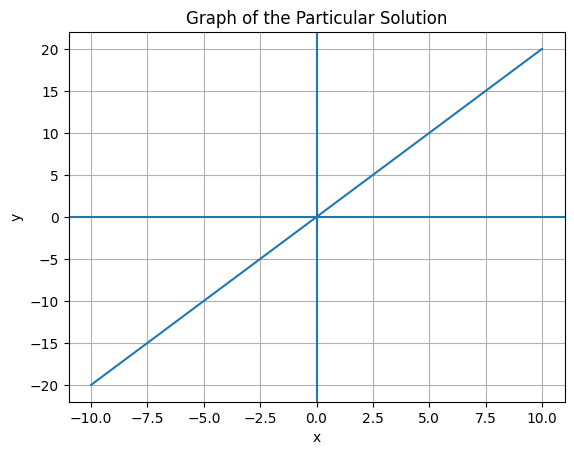

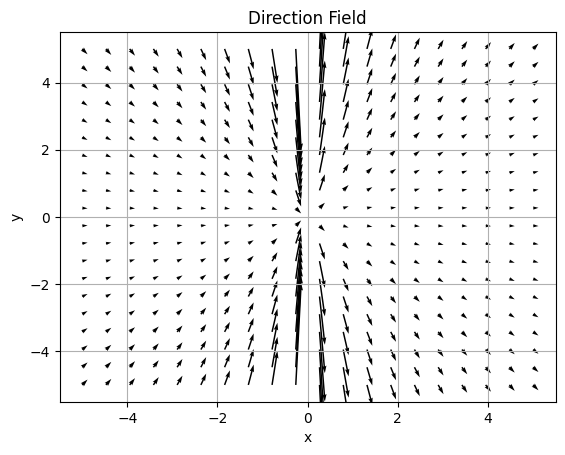

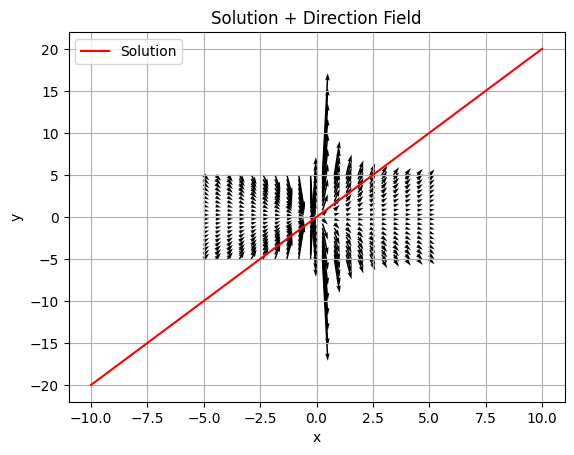

In [ ]:
main()